# **1. 스타버스 주변 소상공인 / 커피 프랜차이즈 입점 전략 분석**

### 1. 분석 목표
- 1. 스타벅스 주변에 커피 전문점이 많이 분포하는가?
- 2. 특정 프랜차이즈는 스타벅스와 가까운 곳에 입점하는 경행이 있는가?
- 3. 어느 자치구에서 스타벅스와 프랜차이즈가 함께 밀집되어 있는가?
- 4. 거리 구간별, 브랜드별, 자치구별, 시각화를 통해 어떤 결론을 낼 수 있는가?

### 2. 분석 주의점
- 이 분석은 위치 데이터 기반의 상관관계 분석임
    - 상관관계: 두 현상이 함께 변하는 관계를 말함. 같이 변한다고 해서 원인과 결과는 아님. 예) 아이스크림 판매량이 증가할수록 익사 사고도 많이 증가한다.
    - 인과관계: 한 현상이 다른 현상의 원인이 되는 관계를 말함. 예) 비가 많이 오면 우산 판매량이 증가한다.
- 소상공인 데이터에 개업일 또는 입ㅈ점 순서가 없어서 "스타벅스가 먼저 생기고 주변에 다른 가게가 생겼다"는 인과관계도 증명할 수 없음



In [1]:
from pathlib import Path
import pandas as pd

In [2]:
BASE_DIR = Path.cwd()
print("현재 작업 폴더:  ", BASE_DIR)
DATA_DIR = BASE_DIR / "data"
print("데이터 폴더: ", DATA_DIR)
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
print("결과 저장 폴더: ", OUTPUT_DIR)

현재 작업 폴더:   c:\heeseung\02_DataAnalysis
데이터 폴더:  c:\heeseung\02_DataAnalysis\data
결과 저장 폴더:  c:\heeseung\02_DataAnalysis\output


In [3]:
STARBUCKS_FILE = 'starbucks_seoul.csv'
SMALL_BIZ_FILE = '소상공인시장진흥공단_상가(상권)정보_서울_202603.csv'
STARBUCKS_FILE = DATA_DIR / STARBUCKS_FILE
SMALL_BIZ_FILE = DATA_DIR / SMALL_BIZ_FILE
print(STARBUCKS_FILE)
print(SMALL_BIZ_FILE)

c:\heeseung\02_DataAnalysis\data\starbucks_seoul.csv
c:\heeseung\02_DataAnalysis\data\소상공인시장진흥공단_상가(상권)정보_서울_202603.csv


In [4]:
df_starbucks_raw = pd.read_csv(STARBUCKS_FILE)
df_starbucks_raw

,store,addr,lat,lng
0,역삼아레나빌딩,서울특별시 강남구 언주로 425 (역삼동),37.501087,127.043069
1,논현역사거리,서울특별시 강남구 강남대로 538 (논현동),37.510178,127.022223
2,신사역성일빌딩,서울특별시 강남구 강남대로 584 (논현동),37.513931,127.020606
3,국기원사거리,서울특별시 강남구 테헤란로 125 (역삼동),37.499517,127.031495
4,대치재경빌딩,서울특별시 강남구 남부순환로 2947 (대치동),37.494668,127.062583
...,...,...,...,...
687,면목역,서울특별시 중랑구 면목로 403 (면목동),37.587880,127.087609
688,묵동,"서울특별시 중랑구 동일로 952 (묵동, 로프트원 태릉입구역) 1층",37.615368,127.076633
689,망우동,서울특별시 중랑구 망우로 407 (망우동),37.599508,127.097539
690,양원역,서울특별시 중랑구 양원역로10길 3 (망우동),37.606654,127.106360


In [5]:
df_raw = pd.read_csv(SMALL_BIZ_FILE)
df_raw

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11268\3999704490.py:1: DtypeWarning: Columns (0: 층정보) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(SMALL_BIZ_FILE)


,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220800800619,참편한공인중개사사무소,NaN,L1,부동산,L102,부동산 서비스,L10203,부동산 중개/대리업,L68221,...,1165010100109270035014757,NaN,서울특별시 서초구 방배로19길 25,137843,6682,NaN,1,NaN,126.993691,37.484844
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,1174010700105020004015779,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810
2,MA010120220809658173,성심인력공사,NaN,N1,시설관리·임대,N104,고용 알선,N10401,고용 알선업,N75110,...,1117010700100430059022991,NaN,서울특별시 용산구 한강대로 385,140821,4320,NaN,NaN,NaN,126.972240,37.552803
3,MA010120220808205276,칸토빈,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,1150010800200200002002536,공항시장역,서울특별시 강서구 방화동로 30,157240,7619,NaN,1,NaN,126.810493,37.563548
4,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,1135010500101690179002482,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,NaN,G2,소매,G214,연료 소매,G21401,주유소,G47711,...,1147010200101210004019571,NaN,서울특별시 양천구 안양천로 1171,158052,7969,NaN,NaN,NaN,126.882157,37.545315
537485,MA0106202601A2413483,뷰티에이지,NaN,S2,수리·개인,S207,이용·미용,S20701,미용실,S96111,...,1168010100107250051023877,NaN,서울특별시 강남구 테헤란로30길 31,135921,6223,NaN,NaN,NaN,127.040045,37.499253
537486,MA0106202601A0824946,리나스 예술의전당점,NaN,I2,음식,I201,한식,I20101,백반/한정식,I56111,...,1165010800107150000021704,NaN,서울특별시 서초구 남부순환로 2406,137718,6757,NaN,NaN,NaN,127.014144,37.480338
537487,MA0106202601A1120245,제이라스 스튜디오,NaN,G2,소매,G209,섬유·의복·신발 소매,G20903,유아용 의류 소매업,G47417,...,1114011200100460031000001,NaN,서울특별시 중구 남대문시장8길 16,100804,4529,NaN,NaN,NaN,126.978315,37.559697


In [6]:
print('스타벅스 원본: ', df_starbucks_raw.shape)
print('소상공인 원본: ', df_raw.shape)

스타벅스 원본:  (692, 4)
소상공인 원본:  (537489, 39)


In [7]:
df_starbucks = df_starbucks_raw.copy()

In [8]:
if {'지점명', '주소', '위도', '경도'}.issubset(df_starbucks.columns):
    df_starbucks = df_starbucks[['지점명','주소','위도', '경도']].copy()
    df_starbucks.columns = ['스타벅스지점명', '스타벅스주소', '스타벅스위도', '스타벅스경도']
elif df_starbucks.shape[1] >= 4:
    df_starbucks = df_starbucks.iloc[:, :4].copy()
    df_starbucks.columns = ['스타벅스지점명', '스타벅스주소', '스타벅스위도', '스타벅스경도']
else:
    raise ValueError('스타벅스 데이터에 최소 4개 컬럼이 필요합니다.')

In [9]:
df_starbucks.info()

<class 'pandas.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   스타벅스지점명  692 non-null    str    
 1   스타벅스주소   692 non-null    str    
 2   스타벅스위도   692 non-null    float64
 3   스타벅스경도   692 non-null    float64
dtypes: float64(2), str(2)
memory usage: 21.8 KB


In [10]:
# 만약 위도, 경고가 문자열이라면 ... 
df_starbucks['스타벅스위도'] = pd.to_numeric(df_starbucks['스타벅스위도'], errors='coerce') # 에러가 날 경우 NaN으로 변환
df_starbucks['스타벅스경도'] = pd.to_numeric(df_starbucks['스타벅스경도'], errors='coerce')

# 만약 스타벅스위도, 스타벅스경도에 NaN이 존재한다면 ... 중복 데이터가 존재한다면 ... 삭제
df_starbucks = df_starbucks.dropna(subset=['스타벅스위도', '스타벅스경도']).drop_duplicates()
df_starbucks.shape

(692, 4)

In [40]:
df_starbucks.info()

<class 'pandas.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   스타벅스지점명  692 non-null    str    
 1   스타벅스주소   692 non-null    str    
 2   스타벅스위도   692 non-null    float64
 3   스타벅스경도   692 non-null    float64
dtypes: float64(2), str(2)
memory usage: 21.8 KB


In [11]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  str    
 1   상호명        537489 non-null  str    
 2   지점명        47001 non-null   str    
 3   상권업종대분류코드  537489 non-null  str    
 4   상권업종대분류명   537489 non-null  str    
 5   상권업종중분류코드  537489 non-null  str    
 6   상권업종중분류명   537489 non-null  str    
 7   상권업종소분류코드  537489 non-null  str    
 8   상권업종소분류명   537489 non-null  str    
 9   표준산업분류코드   537291 non-null  str    
 10  표준산업분류명    537291 non-null  str    
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  str    
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  str    
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  str    
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  str    
 19  지번코드       537489 non-null  int64 

In [12]:
def find_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f'다음 후보 컬럼을 찾을 수 없습니다: {candidates}')

In [13]:
id_col = find_col(df_raw, ['상가업소번호', '상가업소번호명'])
name_col = find_col(df_raw, ['상호명'])
category_l_col = find_col(df_raw, ['상권업종대분류명', '상권업종대분류코드'])
category_m_col = find_col(df_raw, ['상권업종중분류명', '상권업종중분류코드'])
category_s_col = find_col(df_raw, ['상권업종소분류명', '상권업종소분류코드'])
address_col = find_col(df_raw,['도로명주소', '지번주소'])
lat_col = find_col(df_raw,['위도'])
lon_col = find_col(df_raw,['경도'])

In [14]:
use_cols = [id_col, name_col, category_l_col, category_m_col, category_s_col, address_col, lat_col, lon_col]
df_store = df_raw[use_cols].copy()
df_store

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도
0,MA010120220800800619,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,서울특별시 서초구 방배로19길 25,37.484844,126.993691
1,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,서울특별시 강동구 상암로3길 8,37.550810,127.126859
2,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,서울특별시 용산구 한강대로 385,37.552803,126.972240
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493
4,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,서울특별시 노원구 한글비석로23길 2,37.660715,127.071218
...,...,...,...,...,...,...,...,...
537484,MA0106202601A1319837,더지엘에너지(주)목동지점,소매,연료 소매,주유소,서울특별시 양천구 안양천로 1171,37.545315,126.882157
537485,MA0106202601A2413483,뷰티에이지,수리·개인,이용·미용,미용실,서울특별시 강남구 테헤란로30길 31,37.499253,127.040045
537486,MA0106202601A0824946,리나스 예술의전당점,음식,한식,백반/한정식,서울특별시 서초구 남부순환로 2406,37.480338,127.014144
537487,MA0106202601A1120245,제이라스 스튜디오,소매,섬유·의복·신발 소매,유아용 의류 소매업,서울특별시 중구 남대문시장8길 16,37.559697,126.978315


In [15]:
df_store['위도'] = pd.to_numeric(df_store['위도'], errors='coerce')
df_store['경도'] = pd.to_numeric(df_store['경도'], errors='coerce')
df_store = df_store.dropna(subset=['위도', '경도']).drop_duplicates()
df_store.shape

(537489, 8)

In [28]:
# 서울 범위를 크게 벗어난 좌표 제거
df_store = df_store[
    (df_store['위도'].between(37.0, 38.0)) &
    (df_store['경도'].between(126.0, 128.0))
].copy()
df_store.shape

(537489, 8)

In [29]:
df_store.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도
0,MA010120220800800619,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,서울특별시 서초구 방배로19길 25,37.484844,126.993691
1,MA010120220804265295,60계치킨암사,음식,기타 간이,치킨,서울특별시 강동구 상암로3길 8,37.550810,127.126859
2,MA010120220809658173,성심인력공사,시설관리·임대,고용 알선,고용 알선업,서울특별시 용산구 한강대로 385,37.552803,126.972240
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493
4,MA010120220804370987,까치노래연습장,예술·스포츠,유원지·오락,노래방,서울특별시 노원구 한글비석로23길 2,37.660715,127.071218


In [30]:
coffee_keywords = ['커피', '카페', '까페','coffee', 'cafe']
mask_coffee = (df_store['상권업종중분류명'].astype(str).str.contains('커피|카페|음료', na=False)|
                df_store['상권업종소분류명'].astype(str).str.contains('커피|카페|음료', na=False)|
                df_store['상호명'].astype(str).str.contains('|'.join(coffee_keywords), case=False, na=False)
                )
df_cafe = df_store[mask_coffee].copy()
df_cafe.shape

(27250, 8)

In [31]:
brand_patterns = {
	'메가커피': r'메가\s*커피|메가\s*엠지씨|메가MGC|메가\s*MGC|MEGA\s*MGC|MEGA\s*COFFEE',
	'컴포즈커피': r'컴포즈\s*커피|COMPOSE\s*COFFEE',
	'빽다방': r'빽다방|PAIK',
	'이디야': r'이디야|EDIYA',
	'투썸플레이스': r'투썸|A\s*TWOSOME|TWOSOME',
	'할리스': r'할리스|HOLLYS',
	'커피빈': r'커피빈|COFFEE\s*BEAN',
	'파스쿠찌': r'파스쿠찌|PASCUCCI',
	'탐앤탐스': r'탐앤탐스|TOM\s*N\s*TOMS',
	'더벤티': r'더벤티|THE\s*VENTI',
	'매머드커피': r'매머드|MAMMOTH',
	'텐퍼센트커피': r'텐퍼센트|10\s*PERCENT'
}

In [32]:
import re

In [33]:
def extract_brand(name):
    name = str(name).upper()
    for brand, pattern in brand_patterns.items():
        if re.search(pattern, name, flags=re.IGNORECASE):
            return brand

    return '기타커피전문점'   

In [34]:
df_cafe['브랜드명'] = df_cafe['상호명'].apply(extract_brand)
df_cafe.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명
3,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점
51,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방
78,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점
109,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점
118,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점


In [35]:
brand_counts = df_cafe['브랜드명'].value_counts().reset_index()
brand_counts

,브랜드명,count
0,기타커피전문점,23467
1,메가커피,979
2,컴포즈커피,458
3,매머드커피,450
4,이디야,436
5,투썸플레이스,376
6,빽다방,372
7,커피빈,240
8,더벤티,158
9,할리스,115


In [36]:
brand_counts.columns = ['브랜드명', '매장수']
brand_counts

,브랜드명,매장수
0,기타커피전문점,23467
1,메가커피,979
2,컴포즈커피,458
3,매머드커피,450
4,이디야,436
5,투썸플레이스,376
6,빽다방,372
7,커피빈,240
8,더벤티,158
9,할리스,115


In [37]:
import numpy as np

In [38]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """두 지점의 위도/경도를 이용해 거리(m)를 계산합니다."""
    R = 6371000  # 지구 반지름(m)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

In [39]:
# 함수 테스트: 서울시청과 강남역의 대략적인 거리
sample_distance = haversine_distance(37.5665, 126.9780, 37.4979, 127.0276)
print(f'서울시청 ~ 강남역 거리: {sample_distance/1000:.2f}km')

서울시청 ~ 강남역 거리: 8.79km


- 모든 커피전문점과 모든 스타벅스의 거리를 비교한 뒤, 가장 가까운 스타벅스의 거리를 구함
- df_cafe_dist: ['상가업소번호', '상호명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '도로명주소', '위도', '경도'
, '브랜드명', '가장가까운스타벅스', '스타벅스까지거리_m']

In [42]:
# def find_col(df, candidates):
#     for col in candidates:
#         if col in df.columns:
#             return col
#     raise KeyError(f'다음 후보 컬럼을 찾을 수 없습니다: {candidates}')
    
# id_col = find_col(df_starbucks, ['상가업소번호', '상가업소번호명'])
# name_col = find_col(df_starbucks, ['상호명'])
# category_l_col = find_col(df_starbucks, ['상권업종대분류명', '상권업종대분류코드'])
# category_m_col = find_col(df_starbucks, ['상권업종중분류명', '상권업종중분류코드'])
# category_s_col = find_col(df_starbucks, ['상권업종소분류명', '상권업종소분류코드'])
# address_col = find_col(df_starbucks,['도로명주소', '지번주소'])
# lat_col = find_col(df_starbucks,['위도'])
# lon_col = find_col(df_starbucks,['경도'])
# brand_col = find_col(df_starbucks['브랜드명'])
# close_col = find_col(df_starbucks['가장가까운스타벅스'])
# distance_col = find_col(df_starbucks['스타벅스까지거기_m'])


In [48]:
def add_nearest_starbucks(cafe_df, starbucks_df, chunk_size=2000):
    cafe_df = cafe_df.copy().reset_index(drop=True)
    starbucks_df = starbucks_df.copy().reset_index(drop=True)

    sb_lat = starbucks_df['스타벅스위도'].to_numpy()
    sb_lon = starbucks_df['스타벅스경도'].to_numpy()
    sb_name = starbucks_df['스타벅스지점명'].to_numpy()

    nearest_distances = []
    nearest_names = []

    for start in range(0, len(cafe_df), chunk_size):
        end = min(start + chunk_size , len(cafe_df))
        chunk = cafe_df.iloc[start:end]

        # 1차원 배열을 2차원 세로 배열로 바꿈
        # [37.1 37.2 37.3] -> [[37.1][37.2][37.3]]
        cafe_lat = chunk['위도'].to_numpy()[:, None]
        cafe_lon = chunk['경도'].to_numpy()[:, None]

            #         스타벅스1   스타벅스2   스타벅스3 ...
            # 카페1    12000m      2500m      50m
            # 카페2       ..       ..         ..
            # 카페3
    
        dist_matrix = haversine_distance(cafe_lat, cafe_lon, sb_lat[None, :], sb_lon[None, :])
        min_idx = dist_matrix.argmin(axis=1)
        min_dist = dist_matrix.min(axis=1)
        nearest_distances.extend(min_dist)
        nearest_names.extend(sb_name[min_idx])
        print(f"{end:,}/{len(cafe_df):,}개 처리 완료")

    cafe_df["가장가까운스타벅스"] = nearest_names
    cafe_df['스타벅스까지거리_m'] = nearest_distances
    return cafe_df



In [49]:
df_cafe_dist = add_nearest_starbucks(df_cafe, df_starbucks, chunk_size=2000)

2,000/27,250개 처리 완료
4,000/27,250개 처리 완료
6,000/27,250개 처리 완료
8,000/27,250개 처리 완료
10,000/27,250개 처리 완료
12,000/27,250개 처리 완료
14,000/27,250개 처리 완료
16,000/27,250개 처리 완료
18,000/27,250개 처리 완료
20,000/27,250개 처리 완료
22,000/27,250개 처리 완료
24,000/27,250개 처리 완료
26,000/27,250개 처리 완료
27,250/27,250개 처리 완료


In [50]:
df_cafe_dist

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790
...,...,...,...,...,...,...,...,...,...,...,...
27245,MA0106202601A2192126,메이 베이크 커피베이킹,음식,비알코올,카페,서울특별시 서초구 서초대로25길 90,37.491646,126.992175,기타커피전문점,방배,150.978664
27246,MA0106202601A1215762,이룬 스터디카페,예술·스포츠,도서관·사적지,독서실/스터디 카페,서울특별시 용산구 두텁바위로 43,37.545903,126.976972,기타커피전문점,숙대입구역,477.710113
27247,MA0106202601A1360855,메가엠지씨커피 논현동현점,음식,비알코올,카페,서울특별시 강남구 도산대로50길 8,37.521842,127.037319,메가커피,학동사거리,89.550153
27248,MA0106202601A1372250,올드 캐스크,소매,음료 소매,우유 소매업,서울특별시 마포구 월드컵로20길 5,37.557610,126.909232,기타커피전문점,망원역,233.568476


### 거리 구간별 분석
- 0 ~ 50m: 거의 바로 옆
- 50 ~ 100m: 매우 가까움
- 100 ~ 300m: 도보권
- 300 ~ 500m: 인근 상권
- 500 ~ 1km: 같은 생활권
- 1km 이상: 상대적으로 먼거리

In [52]:
bins = [0, 50, 100, 300, 500, 1000, np.inf]
labels = ['0 ~ 50m', '50 ~ 100m', '100 ~ 300m', '300 ~ 500m', '500 ~ 1km', '1km 이상']

df_cafe_dist['거리구간'] = pd.cut(
    df_cafe_dist['스타벅스까지거리_m'], bins = bins, labels = labels, include_lowest = True
)

In [53]:
df_cafe_dist

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m,거리구간
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992,100 ~ 300m
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682,100 ~ 300m
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136,100 ~ 300m
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233,300 ~ 500m
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790,100 ~ 300m
...,...,...,...,...,...,...,...,...,...,...,...,...
27245,MA0106202601A2192126,메이 베이크 커피베이킹,음식,비알코올,카페,서울특별시 서초구 서초대로25길 90,37.491646,126.992175,기타커피전문점,방배,150.978664,100 ~ 300m
27246,MA0106202601A1215762,이룬 스터디카페,예술·스포츠,도서관·사적지,독서실/스터디 카페,서울특별시 용산구 두텁바위로 43,37.545903,126.976972,기타커피전문점,숙대입구역,477.710113,300 ~ 500m
27247,MA0106202601A1360855,메가엠지씨커피 논현동현점,음식,비알코올,카페,서울특별시 강남구 도산대로50길 8,37.521842,127.037319,메가커피,학동사거리,89.550153,50 ~ 100m
27248,MA0106202601A1372250,올드 캐스크,소매,음료 소매,우유 소매업,서울특별시 마포구 월드컵로20길 5,37.557610,126.909232,기타커피전문점,망원역,233.568476,100 ~ 300m


In [54]:
df_cafe_dist.head()

,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,도로명주소,위도,경도,브랜드명,가장가까운스타벅스,스타벅스까지거리_m,거리구간
0,MA010120220808205276,칸토빈,음식,비알코올,카페,서울특별시 강서구 방화동로 30,37.563548,126.810493,기타커피전문점,송정역,291.208992,100 ~ 300m
1,MA010120220812914468,빽다방구산역점,음식,비알코올,카페,서울특별시 은평구 연서로 129,37.610477,126.916688,빽다방,구산역,165.780682,100 ~ 300m
2,MA010120220806903716,맹커피숍,음식,비알코올,카페,서울특별시 은평구 불광로 27,37.610773,126.928818,기타커피전문점,불광역8번출구,135.506136,100 ~ 300m
3,MA010120220802781563,담다,음식,비알코올,카페,서울특별시 동대문구 왕산로19가길 67,37.581067,127.031631,기타커피전문점,고대,365.041233,300 ~ 500m
4,MA010120220802680776,초원,음식,비알코올,카페,서울특별시 동대문구 왕산로 9,37.576284,127.024498,기타커피전문점,신설동역,104.377790,100 ~ 300m


In [59]:
distance_summary = (df_cafe_dist['거리구간'].value_counts().reindex(labels).reset_index())
distance_summary.columns = ['거리구간', '카페수']
distance_summary

,거리구간,카페수
0,0 ~ 50m,1837
1,50 ~ 100m,3138
2,100 ~ 300m,11248
3,300 ~ 500m,5560
4,500 ~ 1km,4675
5,1km 이상,792


In [60]:
distance_summary['비율(%)'] = distance_summary['카페수'] / distance_summary['카페수'].sum() * 100
distance_summary

,거리구간,카페수,비율(%)
0,0 ~ 50m,1837,6.741284
1,50 ~ 100m,3138,11.515596
2,100 ~ 300m,11248,41.277064
3,300 ~ 500m,5560,20.403670
4,500 ~ 1km,4675,17.155963
5,1km 이상,792,2.906422


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns # pip install seaborn

In [67]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

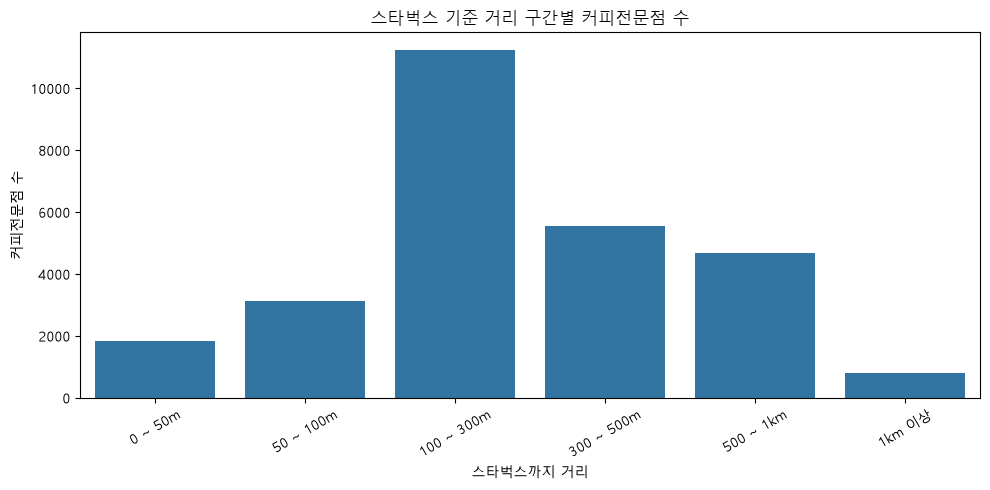

In [68]:
plt.figure(figsize=(10, 5))
sns.barplot(data=distance_summary, x='거리구간', y='카페수')
plt.title('스타벅스 기준 거리 구간별 커피전문점 수')
plt.xlabel('스타벅스까지 거리')
plt.ylabel('커피전문점 수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distance_bucket_count.png', dpi=150, bbox_inches='tight')
plt.show()

### 반경별 누적 분석
거리 구간별 개수도 중요하지만 결론을 내릴떄는 "스타벅스 반경 100m 안에 몇 %가 있는가?" 처럼 누적 비율이 더 직관적

In [69]:
radius_list = [50, 100, 300, 500, 1000]

radius_summary = []
for radius in radius_list:
    count = (df_cafe_dist['스타벅스까지거리_m'] <= radius).sum()
    ratio = count / len(df_cafe_dist) * 100
    radius_summary.append({
        '반경': f'{radius}m 이내',
        '반경_m': radius,
        '카페수': count,
        '비율(%)': ratio
    })

radius_summary = pd.DataFrame(radius_summary)

In [70]:
radius_summary

,반경,반경_m,카페수,비율(%)
0,50m 이내,50,1837,6.741284
1,100m 이내,100,4975,18.256881
2,300m 이내,300,16223,59.533945
3,500m 이내,500,21783,79.937615
4,1000m 이내,1000,26458,97.093578


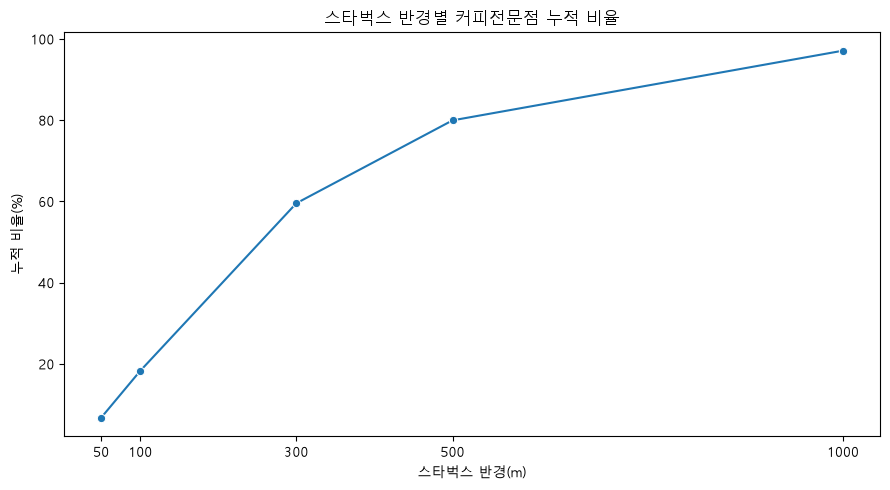

In [71]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=radius_summary, x='반경_m', y='비율(%)', marker='o')
plt.title('스타벅스 반경별 커피전문점 누적 비율')
plt.xlabel('스타벅스 반경(m)')
plt.ylabel('누적 비율(%)')
plt.xticks(radius_list)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'radius_cumulative_ratio.png', dpi=150, bbox_inches='tight')
plt.show()